# lgbm 모델 학습(베이스 코드)
- 이 코드를 통해 연구 진행

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")

Mounted at /content/drive


In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")

# LGB 모델 함수 정의

# 이상치 처리
df = df_raw.copy()
df.columns = [col.split('.')[1] for col in df.columns]
for col in df.columns:
    df[col] = np.where(df[col] == -99, np.nan, df[col])
df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

# 필요없는 컬럼 제거
df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 결측치 제거
df.dropna(inplace=True)

# 날짜 파싱 및 파생 변수 생성
df['tm'] = pd.to_datetime(df['tm'].astype(int), format='%Y%m%d%H')
df['month'] = df['tm'].dt.month
df['hour'] = df['tm'].dt.hour

# 요일 및 주말 여부
df['weekday'] = df['tm'].dt.dayofweek
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (1년 주기)
df['dayofyear'] = df['tm'].dt.dayofyear
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# 더 이상 필요 없는 컬럼 제거
df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

# 데이터 시작부터 현재 시점까지의 평균 온도
# df['ta_expanding_mean'] = df['ta'].expanding(min_periods=1).mean()
# # 데이터 시작부터 현재 시점까지의 습도 표준편차
# df['hm_expanding_std'] = df['hm'].expanding(min_periods=1).std().round(2)


# 바람 방향 범주화
df['quadrant'] = np.select(
    [
        (df['wd'] >= 315) | (df['wd'] < 45),   # 북서
        (df['wd'] >= 45) & (df['wd'] < 135),   # 북동
        (df['wd'] >= 135) & (df['wd'] < 225),  # 남동
        (df['wd'] >= 225) & (df['wd'] < 315)   # 남서
    ],
    [1, 2, 3, 4],
    default=-99  # 이미 -99는 존재하지 않음. 안전기작
)
df.drop('wd', axis=1, inplace=True)

# 강수량 이진화
df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
df.drop('rn_day', axis=1, inplace=True)

# 원-핫 인코딩
df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

# x, y 분리
x = df.drop('heat_demand', axis=1)
y = df['heat_demand']

# 스케일링 및 분할
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor

# 랜덤 포레스트 모델 정의
model = RandomForestRegressor(
    n_estimators=2000,
    max_depth=None,         # 필요 시 제한 가능
    random_state=42,        # 재현성을 위한 seed
    n_jobs=-1               # 병렬처리
)


# 학습
# RandomForest는 단순히 fit만 하면 됩니다
model.fit(x_train, y_train)

rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, model.predict(x_test)))
# 평가 출력
print("랜덤포레스트 결과")
print("RMSE :", rmse)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, model.predict(x_test)))
print("R2   :", sk.metrics.r2_score(y_test, model.predict(x_test)))

# 중요도 추출 (split은 등장 횟수 기준, gain은 손실 감소량 기준)
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 상위 20개 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

# 코드 결과 저장 코드
- 연구 진행시 훈련 함수 train_lgbm_model(df_raw)에 파생변수 추가하시면 예측 및 결과 저장 함수 def preprocess_for_prediction(df_test, train_features)에도 추가한 파생변수 넣어줘야합니다.

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

PATH = "/content/drive/MyDrive/열수요예측/"


try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")

    exit()



def train_lgbm_model(df_raw):
    """
    주어진 데이터로 LightGBM 모델을 훈련하고,
    훈련된 모델과 사용된 피처 목록을 반환합니다.
    """
    df = df_raw.copy()


    df.columns = [col.split('.')[1] if '.' in col else col for col in df.columns]


    for col in df.columns:
        if col != 'tm':
            df[col] = np.where(df[col] == -99, np.nan, df[col])
    df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

    df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)


    df.dropna(inplace=True)

    # 날짜 파싱 및 파생 변수 생성
    df['tm'] = pd.to_datetime(df['tm'].astype(str), format='%Y%m%d%H')
    df['month'] = df['tm'].dt.month
    df['hour'] = df['tm'].dt.hour
    df['weekday'] = df['tm'].dt.dayofweek
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df['dayofyear'] = df['tm'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    # 데이터 시작부터 현재 시점까지의 평균 온도
    # df['ta_expanding_mean'] = df['ta'].expanding(min_periods=1).mean()
    # # 데이터 시작부터 현재 시점까지의 습도 표준편차
    # df['hm_expanding_std'] = df['hm'].expanding(min_periods=1).std().round(2)


    df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)


    df['quadrant'] = np.select(
        [
            (df['wd'] >= 315) | (df['wd'] < 45),   # 북서-북-북동
            (df['wd'] >= 45) & (df['wd'] < 135),  # 동
            (df['wd'] >= 135) & (df['wd'] < 225), # 남동-남-남서
            (df['wd'] >= 225) & (df['wd'] < 315)  # 서
        ],
        [1, 2, 3, 4],
        default=-99
    )
    df.drop('wd', axis=1, inplace=True)


    df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
    df.drop('rn_day', axis=1, inplace=True)


    df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)


    x = df.drop('heat_demand', axis=1)
    y = df['heat_demand']


    train_features = x.columns.tolist()

    # LightGBM 모델 정의 및 학습
    # 전체 훈련 데이터로 학습하여 모델 성능 극대화
    LEARNING_RATE=0.05
    # LightGBM 모델 정의
    model = lgb.LGBMRegressor(
      n_estimators=1000,
      learning_rate=LEARNING_RATE,
      objective='reg:squarederror', # LightGBM의 'regression'과 동일
    )

    model.fit(x, y)

    print("LightGBM 모델 훈련 완료.")

    return model, train_features



def preprocess_for_prediction(df_test, train_features):
    """
    테스트 데이터를 훈련된 모델에 맞게 전처리하고,
    피처 순서까지 정렬하여 반환합니다.
    """
    df = df_test.copy()

    new_column_names_map = {
    'TM': 'tm',
    'branch_ID': 'branch_id', # ID는 소문자 id로 변경
    'TA': 'ta',
    'WD': 'wd',
    'WS': 'ws',
    'RN_DAY': 'rn_day',
    'RN_HR1': 'rn_hr1',
    'HM': 'hm',
    'SI': 'si',
    'ta_chi': 'ta_chi',
    'heat_demand': 'heat_demand'
    }

    df.rename(columns=new_column_names_map, inplace=True)

    for col in df.columns:
        if col != 'tm':
             df[col] = np.where(df[col] == -99, np.nan, df[col])
    if 'wd' in df.columns:
        df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])


    cols_to_drop = ['si', 'rn_hr1', 'ta_chi']

    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df.drop(existing_cols_to_drop, axis=1, inplace=True)

    df['tm'] = pd.to_datetime(df['tm'].astype(str), format='%Y%m%d%H')
    df['month'] = df['tm'].dt.month
    df['hour'] = df['tm'].dt.hour
    df['weekday'] = df['tm'].dt.dayofweek
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df['dayofyear'] = df['tm'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
    #df['ta_expanding_mean'] = df['ta'].expanding(min_periods=1).mean()

    df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

    if 'wd' in df.columns:
        df['quadrant'] = np.select(
            [
                (df['wd'] >= 315) | (df['wd'] < 45),
                (df['wd'] >= 45) & (df['wd'] < 135),
                (df['wd'] >= 135) & (df['wd'] < 225),
                (df['wd'] >= 225) & (df['wd'] < 315)
            ],
            [1, 2, 3, 4],
            default=-99
        )
        df.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df.columns:
        df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
        df.drop('rn_day', axis=1, inplace=True)

    if 'branch_id' in df.columns:
        df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)


    missing_cols = set(train_features) - set(df.columns)
    for c in missing_cols:
        df[c] = 0

    extra_cols = set(df.columns) - set(train_features)
    df.drop(columns=list(extra_cols), inplace=True)

    df = df[train_features]

    return df

# --- 메인 실행 로직 ---


print("--- 모델 훈련 시작 ---")
model, trained_features = train_lgbm_model(df_raw)
print(f"모델이 {len(trained_features)}개의 피처로 훈련되었습니다.")


print("\n--- 테스트 데이터 전처리 시작 ---")
x_test_processed = preprocess_for_prediction(df_test_raw, trained_features)
print("테스트 데이터 전처리 완료.")
print(f"전처리 후 테스트 데이터 shape: {x_test_processed.shape}")


print("\n--- 예측 수행 ---")
predictions = model.predict(x_test_processed)
predictions[predictions < 0] = 0
print("예측 완료.")


print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = predictions

submission_filename = '250275.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

--- 모델 훈련 시작 ---
LightGBM 모델 훈련 완료.
모델이 28개의 피처로 훈련되었습니다.

--- 테스트 데이터 전처리 시작 ---


<ipython-input-2-3623356230>:173: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
<ipython-input-2-3623356230>:174: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


테스트 데이터 전처리 완료.
전처리 후 테스트 데이터 shape: (166915, 28)

--- 예측 수행 ---
예측 완료.

--- 제출 파일 생성 ---
'250275.csv' 파일이 성공적으로 생성되었습니다.
생성된 파일 상위 5개 행:
           TM branch_ID   TA     WD   WS  RN_DAY  RN_HR1    HM    SI  ta_chi  \
0  2024010100         A  0.5  171.3  0.8     2.5     0.0  97.1 -99.0     0.3   
1  2024010101         A  0.4   93.7  1.0     0.0     0.0  96.8 -99.0     0.1   
2  2024010102         A -0.1  133.0  0.8     0.0     0.0  97.0 -99.0     0.0   
3  2024010103         A -0.8  218.6  0.6     0.0     0.0  96.9 -99.0    -0.2   
4  2024010104         A  0.1   58.7  1.5     0.0     0.0  97.0 -99.0    -0.1   

   heat_demand  
0   225.664215  
1   212.072189  
2   208.510376  
3   206.841995  
4   208.153168  


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# --- 경로 설정 ---
# 본인의 파일 경로에 맞게 수정해주세요.
PATH = "/content/drive/MyDrive/열수요예측/"

# --- 데이터 로드 ---
try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()


def train_lgbm_model(df_raw):
    """
    주어진 데이터로 LightGBM 모델을 훈련하고,
    훈련된 모델, 사용된 피처 목록, 결측치 처리에 사용된 중간값을 반환합니다.
    """
    df = df_raw.copy()

    # 컬럼명 정리
    df.columns = [col.split('.')[1] if '.' in col else col for col in df.columns]

    # -99 값을 np.nan으로 변경
    for col in df.columns:
        if col != 'tm':
            df[col] = np.where(df[col] == -99, np.nan, df[col])
    if 'wd' in df.columns: # 'wd'가 있는지 확인 후 처리
        df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

    # 불필요한 피처 제거
    df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

    # *** 변경점: 숫자형 열에 대해서만 중간값으로 결측치 채우기 ***
    # 1. 숫자형 열만 선택합니다.
    numeric_cols = df.select_dtypes(include=np.number).columns

    # 2. 선택된 숫자형 열에 대해서만 중간값을 계산합니다.
    medians = df[numeric_cols].median()

    # 3. 해당 열들의 결측치만 중간값으로 채웁니다.
    df[numeric_cols] = df[numeric_cols].fillna(medians)


    # 날짜 파싱 및 파생 변수 생성
    df['tm'] = pd.to_datetime(df['tm'].astype(str), format='%Y%m%d%H')
    df['month'] = df['tm'].dt.month
    df['hour'] = df['tm'].dt.hour
    df['weekday'] = df['tm'].dt.dayofweek
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df['dayofyear'] = df['tm'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

    # 풍향(wd) 범주화
    df['quadrant'] = np.select(
        [
            (df['wd'] >= 315) | (df['wd'] < 45),   # 북서-북-북동
            (df['wd'] >= 45) & (df['wd'] < 135),  # 동
            (df['wd'] >= 135) & (df['wd'] < 225), # 남동-남-남서
            (df['wd'] >= 225) & (df['wd'] < 315)  # 서
        ],
        [1, 2, 3, 4],
        default=-99 # 혹시 모를 결측치는 -99로 처리
    )
    df.drop('wd', axis=1, inplace=True)

    # 강수 여부(rn_day) 이진화
    df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
    df.drop('rn_day', axis=1, inplace=True)

    # 지점 ID 원-핫 인코딩
    df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

    # 훈련 데이터 분리
    x = df.drop('heat_demand', axis=1)
    y = df['heat_demand']

    train_features = x.columns.tolist()

    # LightGBM 모델 정의 및 학습
    LEARNING_RATE=0.05
    model = lightgbm.LGBMRegressor(
      n_estimators=1000,
      learning_rate=LEARNING_RATE,
      objective='regression',
    )

    model.fit(x, y)

    print("LightGBM 모델 훈련 완료.")

    # 모델, 피처 목록, 중간값 반환
    return model, train_features, medians


def preprocess_for_prediction(df_test, train_features, medians):
    """
    테스트 데이터를 훈련된 모델에 맞게 전처리하고,
    피처 순서까지 정렬하여 반환합니다.
    """
    df = df_test.copy()

    # 컬럼명 훈련 데이터와 동일하게 변경
    new_column_names_map = {
        'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
        'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
        'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
    }
    df.rename(columns=new_column_names_map, inplace=True)

    # -99 값을 np.nan으로 변경
    for col in df.columns:
        if col != 'tm':
            df[col] = np.where(df[col] == -99, np.nan, df[col])
    if 'wd' in df.columns:
        df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

    # 불필요한 피처 제거
    cols_to_drop = ['si', 'rn_hr1', 'ta_chi']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df.drop(existing_cols_to_drop, axis=1, inplace=True)

    # 훈련 데이터와 동일한 전처리 적용
    df['tm'] = pd.to_datetime(df['tm'].astype(str), format='%Y%m%d%H')
    df['month'] = df['tm'].dt.month
    df['hour'] = df['tm'].dt.hour
    df['weekday'] = df['tm'].dt.dayofweek
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df['dayofyear'] = df['tm'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

    if 'wd' in df.columns:
        df['quadrant'] = np.select(
            [
                (df['wd'] >= 315) | (df['wd'] < 45),
                (df['wd'] >= 45) & (df['wd'] < 135),
                (df['wd'] >= 135) & (df['wd'] < 225),
                (df['wd'] >= 225) & (df['wd'] < 315)
            ],
            [1, 2, 3, 4],
            default=-99
        )
        df.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df.columns:
        df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
        df.drop('rn_day', axis=1, inplace=True)

    if 'branch_id' in df.columns:
        df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

    # *** 변경점: 훈련 데이터의 중간값으로 결측치 채우기 ***
    df.fillna(medians, inplace=True)

    # 그래도 남은 결측치가 있다면 이전/이후 값으로 채우기 (안전장치)
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)

    # 훈련/테스트 데이터 간 피처 맞추기
    missing_cols = set(train_features) - set(df.columns)
    for c in missing_cols:
        df[c] = 0

    extra_cols = set(df.columns) - set(train_features)
    if 'heat_demand' in extra_cols:
        extra_cols.remove('heat_demand') # heat_demand는 예측 대상이므로 제거하지 않음
    df.drop(columns=list(extra_cols), inplace=True, errors='ignore')

    # 피처 순서 맞추기
    df = df[train_features]

    return df

# --- 메인 실행 로직 ---

print("--- 모델 훈련 시작 ---")
# *** 변경점: medians(중간값) 반환 받기 ***
model, trained_features, medians = train_lgbm_model(df_raw)
print(f"모델이 {len(trained_features)}개의 피처로 훈련되었습니다.")
print("결측치 처리에 사용된 중간값:")
print(medians)

print("\n--- 테스트 데이터 전처리 시작 ---")
# *** 변경점: medians(중간값)를 인자로 전달 ***
x_test_processed = preprocess_for_prediction(df_test_raw, trained_features, medians)
print("테스트 데이터 전처리 완료.")
print(f"전처리 후 테스트 데이터 shape: {x_test_processed.shape}")
# 전처리 후 결측치 확인
print(f"전처리 후 남은 결측치 수: {x_test_processed.isnull().sum().sum()}")


print("\n--- 예측 수행 ---")
predictions = model.predict(x_test_processed)
# 예측값이 0보다 작으면 0으로 처리
predictions[predictions < 0] = 0
print("예측 완료.")


print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = predictions

submission_filename = 'submission_median_filled.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

--- 모델 훈련 시작 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 499301, number of used features: 28
[LightGBM] [Info] Start training from score 95.869017
LightGBM 모델 훈련 완료.
모델이 28개의 피처로 훈련되었습니다.
결측치 처리에 사용된 중간값:
tm             2.022070e+09
ta             1.470000e+01
wd             2.216000e+02
ws             1.200000e+00
rn_day         0.000000e+00
hm             6.760000e+01
heat_demand    5.500000e+01
dtype: float64

--- 테스트 데이터 전처리 시작 ---


<ipython-input-4-1582324109>:170: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
<ipython-input-4-1582324109>:171: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


테스트 데이터 전처리 완료.
전처리 후 테스트 데이터 shape: (166915, 28)
전처리 후 남은 결측치 수: 0

--- 예측 수행 ---
예측 완료.

--- 제출 파일 생성 ---
'submission_median_filled.csv' 파일이 성공적으로 생성되었습니다.
생성된 파일 상위 5개 행:
           TM branch_ID   TA     WD   WS  RN_DAY  RN_HR1    HM    SI  ta_chi  \
0  2024010100         A  0.5  171.3  0.8     2.5     0.0  97.1 -99.0     0.3   
1  2024010101         A  0.4   93.7  1.0     0.0     0.0  96.8 -99.0     0.1   
2  2024010102         A -0.1  133.0  0.8     0.0     0.0  97.0 -99.0     0.0   
3  2024010103         A -0.8  218.6  0.6     0.0     0.0  96.9 -99.0    -0.2   
4  2024010104         A  0.1   58.7  1.5     0.0     0.0  97.0 -99.0    -0.1   

   heat_demand  
0   231.948696  
1   219.239700  
2   210.254570  
3   205.061902  
4   209.902354  


# 내일 이거 테스트해보기!

✅ 데이터 로드 성공!

--- 1. 훈련 데이터 전처리 시작 ---
훈련 데이터 전처리 완료.

--- 2. 과적합 진단을 위한 훈련/검증 데이터 분리 ---
훈련 데이터 shape: (399440, 30)
검증 데이터 shape: (99861, 30)

--- 3. LightGBM 모델 정의 및 훈련 시작 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1700
[LightGBM] [Info] Number of data points in the train set: 399440, number of used features: 30
[LightGBM] [Info] Start training from score 95.889703
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 15.3756	valid_0's l2: 236.408

--- 4. 훈련 및 검증 데이터에 대한 성능 평가 (RMSE) ---

훈련 데이터 최종 RMSE: 14.7278
검증 데이터 최종 RMSE: 15.3756
✅ 모델이 안정적으로 훈련된 것으로 보입니다!

--- 5. 피처 중요도 시각화 ---


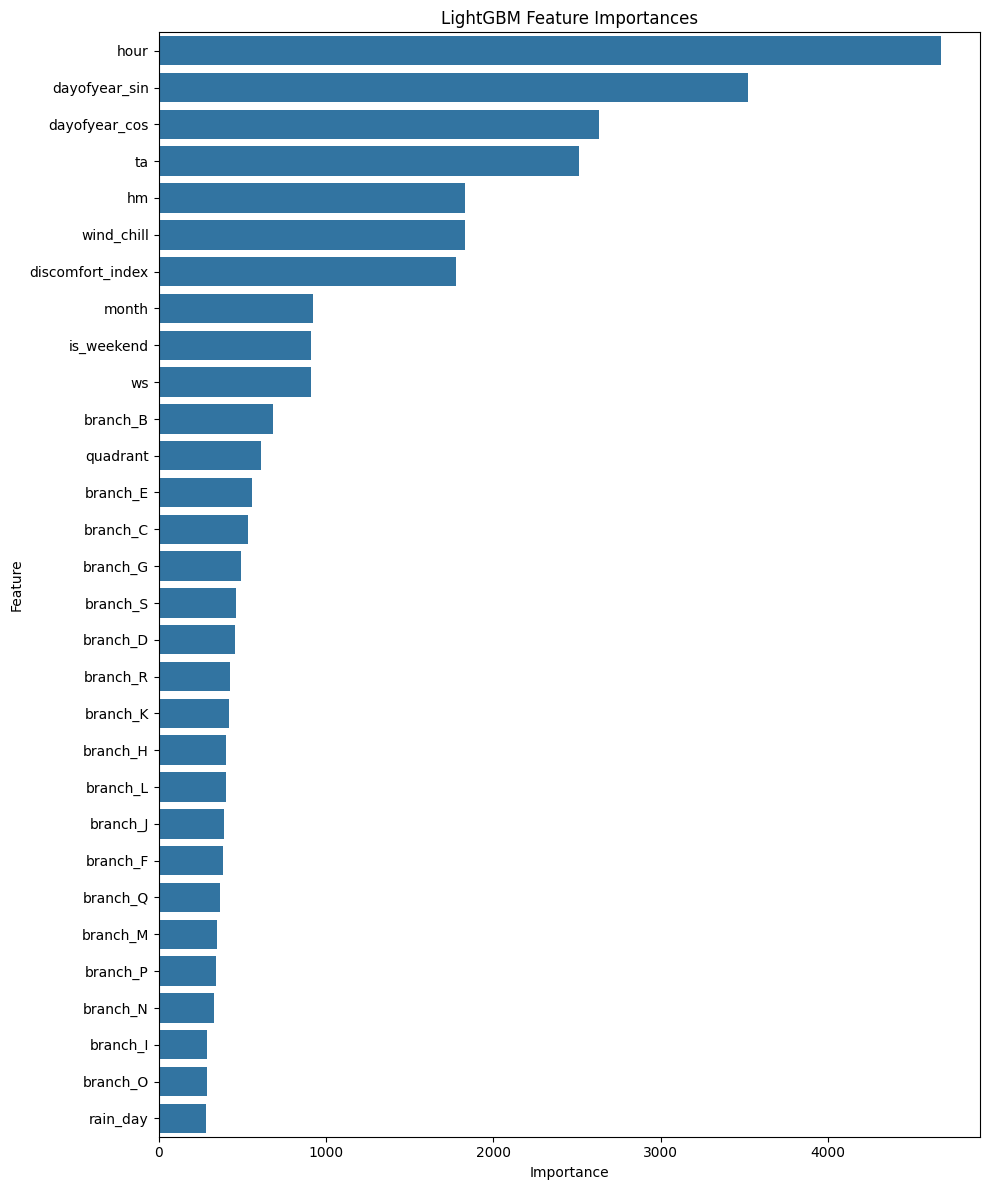


--- 6. 테스트 데이터 전처리 및 예측 수행 ---

--- 7. 제출 파일 생성 ---
'submission_lgbm_improved_final.csv' 파일이 성공적으로 생성되었습니다.
생성된 파일 상위 5개 행:
           TM branch_ID   TA     WD   WS  RN_DAY  RN_HR1    HM    SI  ta_chi  \
0  2024010100         A  0.5  171.3  0.8     2.5     0.0  97.1 -99.0     0.3   
1  2024010101         A  0.4   93.7  1.0     0.0     0.0  96.8 -99.0     0.1   
2  2024010102         A -0.1  133.0  0.8     0.0     0.0  97.0 -99.0     0.0   
3  2024010103         A -0.8  218.6  0.6     0.0     0.0  96.9 -99.0    -0.2   
4  2024010104         A  0.1   58.7  1.5     0.0     0.0  97.0 -99.0    -0.1   

   heat_demand  
0   228.643129  
1   216.652308  
2   208.593908  
3   202.752896  
4   206.177910  

--- 파이프라인 실행 완료 ---
최종 훈련 RMSE: 14.7278
최종 검증 RMSE: 15.3756


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 메시지를 무시합니다.
warnings.filterwarnings('ignore')

# ------------------------- 1. 데이터 로드 설정 -------------------------
# 파일 경로는 사용자의 환경에 맞게 수정해주세요.
# 예: PATH = "C:/Users/사용자명/Documents/데이터폴더/" 또는 PATH = "/Users/사용자명/데이터폴더/"
PATH = "/content/drive/MyDrive/열수요예측/" # Colab 환경 예시

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("✅ 데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# ------------------------- 2. 전처리 및 피처 엔지니어링 함수 -------------------------
def preprocess_data(df_raw_input, is_train=True):
    """
    훈련 데이터와 테스트 데이터에 대한 전처리를 수행하는 통합 함수.
    파생변수 생성, 결측치 처리, 시간 관련 피처 생성을 포함합니다.
    """
    df = df_raw_input.copy()

    # --- 1. 컬럼명 정리 및 기본 결측치/이상치 처리 ---
    if is_train:
        # 훈련 데이터 컬럼명 정리: 'branch.branch_ID' -> 'branch_ID'
        df.columns = [col.split('.')[1] if '.' in col else col for col in df.columns]
    else:
        # 테스트 데이터 컬럼명 매핑 (원본 컬럼명과 통일)
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd', 'WS': 'ws',
            'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm', 'SI': 'si',
            'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand' # heat_demand는 테스트에 없지만, 통일을 위해 포함
        }
        df.rename(columns=new_column_names_map, inplace=True)

    # 특정 오류 값 (-99, 음수)을 NaN으로 처리
    for col in df.columns:
        if col != 'tm': # 시간 컬럼은 제외
            df[col] = np.where(df[col] == -99, np.nan, df[col])

    # 풍향(wd)의 음수 값은 NaN으로 처리
    if 'wd' in df.columns:
        df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

    # 불필요한 컬럼 제거 (존재하는 경우에만 제거)
    cols_to_drop = ['si', 'rn_hr1', 'ta_chi']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    if existing_cols_to_drop:
        df.drop(existing_cols_to_drop, axis=1, inplace=True)

    # --- 2. 시계열 특성 활용 결측치 처리 (ffill, bfill) ---
    # ffill: 이전 시점의 값으로 채움
    df.fillna(method='ffill', inplace=True)
    # bfill: ffill 후 남은 맨 앞 결측치 처리 (만약 데이터 시작점에 결측치가 있다면)
    df.fillna(method='bfill', inplace=True)

    # --- 3. 파생변수 생성 (Feature Engineering) ---
    # 체감온도 (Wind Chill) 계산: 기온과 풍속 이용
    # ws 단위를 m/s 에서 km/h 로 변환 ( * 3.6)
    if 'ta' in df.columns and 'ws' in df.columns:
        df['wind_chill'] = 13.12 + 0.6215 * df['ta'] - 11.37 * (df['ws'] * 3.6)**0.16 + 0.3965 * df['ta'] * (df['ws'] * 3.6)**0.16

    # 불쾌지수 (Discomfort Index) 계산: 기온과 습도 이용
    if 'ta' in df.columns and 'hm' in df.columns:
        df['discomfort_index'] = 9/5 * df['ta'] - 0.55 * (1 - df['hm']/100) * (9/5 * df['ta'] - 26) + 32

    # --- 4. 시간 관련 피처 생성 ---
    if 'tm' in df.columns:
        df['tm'] = pd.to_datetime(df['tm'].astype(str), format='%Y%m%d%H')
        df['month'] = df['tm'].dt.month
        df['hour'] = df['tm'].dt.hour
        df['weekday'] = df['tm'].dt.dayofweek
        df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
        df['dayofyear'] = df['tm'].dt.dayofyear
        df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
        df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
        df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

    # --- 5. 범주형 변수 처리 ---
    # 풍향(wd)을 4개의 사분면으로 변환
    if 'wd' in df.columns:
        df['quadrant'] = pd.cut(df['wd'], bins=[-1, 45, 135, 225, 315, 361], labels=[1, 2, 3, 4, 1], ordered=False).astype(int)
        df.drop('wd', axis=1, inplace=True)

    # 강수 여부 이진 변수 생성
    if 'rn_day' in df.columns:
        df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
        df.drop('rn_day', axis=1, inplace=True)

    # branch_id 원-핫 인코딩
    if 'branch_id' in df.columns:
        df = pd.get_dummies(df, columns=['branch_id'], prefix='branch', drop_first=True)

    return df

# ------------------------- 3. 메인 실행 로직 -------------------------
def run_lgbm_pipeline(train_df_raw, test_df_raw, target_col='heat_demand', save_path='submission_lgbm_improved.csv'):

    print("\n--- 1. 훈련 데이터 전처리 시작 ---")
    df_train = preprocess_data(train_df_raw, is_train=True)
    print("훈련 데이터 전처리 완료.")

    # 훈련을 위한 피처와 타겟 분리
    X = df_train.drop(target_col, axis=1)
    y = df_train[target_col]
    train_features = X.columns.tolist() # 훈련 시 사용된 피처 목록 저장

    print("\n--- 2. 과적합 진단을 위한 훈련/검증 데이터 분리 ---")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"훈련 데이터 shape: {X_train.shape}")
    print(f"검증 데이터 shape: {X_val.shape}")

    print("\n--- 3. LightGBM 모델 정의 및 훈련 시작 ---")
    lgbm_model = lgb.LGBMRegressor(
        random_state=42,
        n_estimators=1000,         # 충분히 큰 값으로 설정하고 Early Stopping으로 조절
        learning_rate=0.05,        # 학습률
        max_depth=10,              # 트리의 최대 깊이
        num_leaves=31,             # 리프 노드의 수
        colsample_bytree=0.8,      # 트리마다 사용할 피처의 비율
        subsample=0.8,             # 데이터를 샘플링하는 비율
        reg_alpha=0.1,             # L1 정규화
        reg_lambda=0.1,            # L2 정규화
        n_jobs=-1                  # 모든 코어 사용
    )

    # Early Stopping을 사용하여 최적의 트리 개수를 찾고 과적합 방지
    lgbm_model.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)],
                   eval_metric='rmse',
                   callbacks=[lgb.early_stopping(100, verbose=True)]) # 100번 동안 성능 향상이 없으면 중단

    print("\n--- 4. 훈련 및 검증 데이터에 대한 성능 평가 (RMSE) ---")
    train_pred = lgbm_model.predict(X_train)
    val_pred = lgbm_model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    print(f"\n훈련 데이터 최종 RMSE: {train_rmse:.4f}")
    print(f"검증 데이터 최종 RMSE: {val_rmse:.4f}")

    if train_rmse * 1.1 < val_rmse: # 훈련 오차보다 검증 오차가 10% 이상 크면 경고
        print(f"👉 경고: 여전히 과적합 경향이 있습니다. (검증 오차 > 훈련 오차)")
    else:
        print("✅ 모델이 안정적으로 훈련된 것으로 보입니다!")

    print("\n--- 5. 피처 중요도 시각화 ---")
    feature_importances = pd.Series(lgbm_model.feature_importances_, index=train_features).sort_values(ascending=False)
    plt.figure(figsize=(10, len(feature_importances) * 0.4)) # 피처 개수에 따라 높이 조절
    sns.barplot(x=feature_importances, y=feature_importances.index)
    plt.title('LightGBM Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout() # 그래프 요소들이 잘 보이도록 레이아웃 조정
    plt.show()

    print("\n--- 6. 테스트 데이터 전처리 및 예측 수행 ---")
    df_test = preprocess_data(test_df_raw, is_train=False)

    # 훈련 시점에는 없었지만 테스트 데이터에만 있는 branch_id 원-핫 인코딩 컬럼이 있을 수 있으므로,
    # 훈련 때 사용한 피처 목록을 기준으로 테스트 데이터의 컬럼을 맞춥니다.
    # 훈련에는 있었지만 테스트에 없는 컬럼은 0으로 채우고, 테스트에만 있는 컬럼은 버립니다.
    test_cols = df_test.columns.tolist()
    missing_in_test = set(train_features) - set(test_cols)
    extra_in_test = set(test_cols) - set(train_features)

    for c in missing_in_test:
        df_test[c] = 0 # 훈련에 있었으나 테스트에 없는 컬럼은 0으로 채움

    if extra_in_test:
        df_test.drop(columns=list(extra_in_test), inplace=True) # 테스트에만 있는 컬럼은 버림

    df_test = df_test[train_features] # 컬럼 순서를 훈련 데이터와 동일하게 맞춤

    predictions = lgbm_model.predict(df_test)
    predictions[predictions < 0] = 0 # 예측값이 0보다 작을 수 없으므로 처리

    print("\n--- 7. 제출 파일 생성 ---")
    submission_df = test_df_raw.copy()
    submission_df[target_col] = predictions
    submission_df.to_csv(save_path, index=False)

    print(f"'{save_path}' 파일이 성공적으로 생성되었습니다.")
    print("생성된 파일 상위 5개 행:")
    print(submission_df.head())

    return lgbm_model, train_rmse, val_rmse, predictions # 모델, RMSE, 예측값 반환

# ------------------------- 파이프라인 실행 -------------------------
if __name__ == "__main__":
    # run_lgbm_pipeline 함수를 호출하여 전체 파이프라인 실행
    final_model, final_train_rmse, final_val_rmse, final_predictions = \
        run_lgbm_pipeline(df_raw, df_test_raw, target_col='heat_demand', save_path='submission_lgbm_improved_final.csv')

    print("\n--- 파이프라인 실행 완료 ---")
    print(f"최종 훈련 RMSE: {final_train_rmse:.4f}")
    print(f"최종 검증 RMSE: {final_val_rmse:.4f}")

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --- 1. 데이터 로드 및 기본 전처리 ---
# 실제 파일 경로에 맞게 수정하세요.


# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"

df_raw = pd.read_csv(PATH + "train_heat.csv")
df_test = pd.read_csv('test_data.csv')

# 제공된 이미지의 정보를 바탕으로 가상 데이터프레임 생성 (실제 데이터 로드 코드로 대체 필요)
# 학습 기간: 2021-01-01 ~ 2023-12-31, 검증 기간: 2024-01-01 ~ 2024-12-31
# 시간 단위 데이터이므로 (3 * 365 + 1) * 24 * 19개 지점의 훈련 데이터가 있을 것으로 예상됩니다.
# 여기서는 코드의 실행 흐름을 보여주기 위해 작은 샘플 데이터를 생성합니다.
# **실제 분석 시에는 아래 샘플 생성 부분을 지우고 자신의 데이터 로드 코드를 사용하세요.**

# --- Dummy Data Generation START (이 부분은 실제 데이터 로드로 대체) ---
print("실제 데이터가 없으므로, 데모용 샘플 데이터를 생성합니다.")
branches = [f'branch_{i}' for i in range(1, 20)]
train_dates = pd.to_datetime(pd.date_range('2023-11-01', '2023-12-31', freq='H'))
test_dates = pd.to_datetime(pd.date_range('2024-01-01', '2024-01-07', freq='H'))
train_data = []
for branch in branches:
    for date in train_dates:
        train_data.append({'date': date, 'branch_ID': branch})
df_train = pd.DataFrame(train_data)

test_data = []
for branch in branches:
    for date in test_dates:
        test_data.append({'date': date, 'branch_ID': branch})
df_test = pd.DataFrame(test_data)

# 컬럼 정보에 맞춰 랜덤 데이터 채우기 (데모용)
for df in [df_train, df_test]:
    df['tm'] = df['date'].dt.hour
    df['ta'] = np.random.uniform(-10, 25, size=len(df))
    df['wd'] = np.random.uniform(0, 360, size=len(df))
    df['ws'] = np.random.uniform(0, 10, size=len(df))
    df['rn_day'] = np.random.uniform(0, 50, size=len(df))
    df['rn_hr1'] = np.random.uniform(0, 5, size=len(df))
    df['hm'] = np.random.uniform(20, 90, size=len(df))
    df['si'] = np.random.uniform(0, 4, size=len(df))
    df['ta_chi'] = df['ta'] - df['ws'] * 0.5
    # 결측치(-99.0) 시뮬레이션
    for col in ['ta', 'ws', 'hm']:
        if np.random.rand() < 0.1:
            df.loc[np.random.choice(df.index, size=int(len(df)*0.05)), col] = -99.0

# heat_demand는 훈련 데이터에만 존재
df_train['heat_demand'] = np.random.uniform(10, 100, size=len(df_train)) - df_train['ta'] * 2
df_train.loc[df_train['heat_demand'] < 0, 'heat_demand'] = 0
# --- Dummy Data Generation END ---


print("훈련 데이터 shape (초기):", df_train.shape)
print("테스트 데이터 shape (초기):", df_test.shape)

# 결측값(-99.0)을 NaN으로 변환
df_train.replace(-99.0, np.nan, inplace=True)
df_test.replace(-99.0, np.nan, inplace=True)

# 시계열 데이터이므로 시간 순서대로 정렬 후 선형 보간법으로 결측치 채우기
# 각 지점별로 따로 보간을 적용해야 하므로 GroupBy 사용
df_train = df_train.sort_values(by=['branch_ID', 'date']).groupby('branch_ID').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)
df_test = df_test.sort_values(by=['branch_ID', 'date']).groupby('branch_ID').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)

# 보간 후에도 남은 NaN이 있다면 앞/뒤 값으로 채우기 (데이터 시작/끝 부분)
df_train.fillna(method='ffill', inplace=True)
df_train.fillna(method='bfill', inplace=True)
df_test.fillna(method='ffill', inplace=True)
df_test.fillna(method='bfill', inplace=True)

print("\n결측치 처리 후 훈련 데이터 NaN 개수:", df_train.isnull().sum().sum())
print("결측치 처리 후 테스트 데이터 NaN 개수:", df_test.isnull().sum().sum())


# --- 2. 피처 엔지니어링 ---
def feature_engineering(df):
    """데이터프레임에 피처를 추가하는 함수"""
    # 'date' 컬럼이 없다면 생성 (tm 컬럼과 연/월/일 정보가 따로 있다면 이를 조합)
    # 이 예제에서는 'date'가 이미 있다고 가정
    if 'date' not in df.columns:
        # 이 부분은 실제 데이터의 날짜 관련 컬럼 구성에 맞게 수정 필요
        # 예: df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + ...)
        pass

    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['hour'] = df['date'].dt.hour # 'tm' 컬럼이 이미 있지만, datetime 객체에서 추출하는 것이 안전
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dayofyear'] = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

    # 시간의 주기성을 나타내기 위한 sin/cos 변환
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # 지점(branch_ID)을 범주형 데이터로 변환
    df['branch_ID'] = df['branch_ID'].astype('category')

    # 지연(Lag) 및 이동평균(Rolling) 피처 생성 (지점별로 계산)
    # 이 작업은 시간이 오래 걸릴 수 있음
    lag_features = ['heat_demand', 'ta', 'ta_chi', 'ws']
    window_sizes = [6, 12, 24] # 6시간, 12시간, 24시간

    # heat_demand는 훈련 데이터에만 존재하므로 따로 처리
    if 'heat_demand' in df.columns:
        for window in window_sizes:
            # 지연 피처 (과거의 값)
            df[f'heat_demand_lag_{window}'] = df.groupby('branch_ID')['heat_demand'].transform(lambda x: x.shift(window))
            # 이동 평균 피처 (과거 기간의 평균)
            df[f'heat_demand_rolling_mean_{window}'] = df.groupby('branch_ID')['heat_demand'].transform(lambda x: x.shift(1).rolling(window).mean())
            df[f'heat_demand_rolling_std_{window}'] = df.groupby('branch_ID')['heat_demand'].transform(lambda x: x.shift(1).rolling(window).std())

    # 기상 변수에 대한 지연 및 이동평균 피처
    weather_features = ['ta', 'ta_chi', 'ws', 'hm']
    for feature in weather_features:
        for window in window_sizes:
            df[f'{feature}_lag_{window}'] = df.groupby('branch_ID')[feature].transform(lambda x: x.shift(window))
            df[f'{feature}_rolling_mean_{window}'] = df.groupby('branch_ID')[feature].transform(lambda x: x.shift(1).rolling(window).mean())

    # 생성된 Lag/Rolling 피처의 결측치는 다시 보간
    df = df.groupby('branch_ID').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)
    df.fillna(method='bfill', inplace=True) # 데이터 앞부분 결측치 채우기

    return df

# heat_demand를 포함한 전체 데이터프레임을 만들어 한번에 피처 엔지니어링 후 다시 분리
# 이렇게 하면 훈련/테스트 데이터 간 피처 생성 시 데이터가 유출되지 않으면서 일관성을 유지할 수 있음
df_test['heat_demand'] = np.nan # 테스트셋에는 타겟 변수가 없으므로 NaN으로 채움
combined_df = pd.concat([df_train, df_test], ignore_index=True)

print("\n피처 엔지니어링 시작...")
combined_df = feature_engineering(combined_df)
print("피처 엔지니어링 완료.")

# 훈련 데이터와 테스트 데이터 다시 분리
df_train_processed = combined_df[combined_df['date'] < '2024-01-01'].copy()
df_test_processed = combined_df[combined_df['date'] >= '2024-01-01'].copy()

# 'heat_demand'는 예측 대상이므로 테스트셋에서 제거
df_test_processed.drop('heat_demand', axis=1, inplace=True)


# --- 3. 모델 학습 및 예측 ---
# 사용할 피처 선택
# 'date'는 모델 학습에 직접 사용하지 않음 (시간 정보를 담은 파생 변수들을 사용)
# 원본 시계열 변수 일부는 유지 (tm은 hour로 대체)
features = [col for col in df_train_processed.columns if col not in ['date', 'heat_demand', 'tm']]
target = 'heat_demand'

# 범주형 피처 지정
categorical_features = ['branch_ID', 'month', 'dayofweek', 'hour']

print(f"\n총 {len(features)}개의 피처를 사용하여 학습합니다.")

# LightGBM 모델 파라미터 설정
# RMSE를 줄이는 데 효과적인 파라미터 조합
params = {
    'objective': 'regression_l1', # MAE, 이상치에 덜 민감하여 안정적. regression(L2) or regression_l1(L1)
    'metric': 'rmse',
    'n_estimators': 2000,         # 나무의 개수
    'learning_rate': 0.01,        # 학습률
    'feature_fraction': 0.8,      # 각 트리마다 사용할 피처의 비율
    'bagging_fraction': 0.8,      # 데이터 샘플링 비율 (과적합 방지)
    'bagging_freq': 1,
    'lambda_l1': 0.1,             # L1 정규화
    'lambda_l2': 0.1,             # L2 정규화
    'num_leaves': 31,             # 리프 노드의 수
    'verbose': -1,
    'n_jobs': -1,                 # 모든 CPU 코어 사용
    'seed': 42,
    'boosting_type': 'gbdt',
}

# 최종 모델은 전체 훈련 데이터(2021-2023)로 학습
print("\n최종 모델 학습 시작...")
model = lgb.LGBMRegressor(**params)

model.fit(df_train_processed[features], df_train_processed[target],
          categorical_feature=categorical_features)

print("모델 학습 완료.")

# 테스트 데이터(2024)에 대한 예측 수행
predictions = model.predict(df_test_processed[features])

# 예측 결과가 음수일 경우 0으로 변환 (열수요는 음수일 수 없음)
predictions[predictions < 0] = 0


# --- 4. 결과 제출 ---
# 제출 파일 생성
# 실제 대회에서 요구하는 제출 양식에 맞게 수정 필요
submission = pd.DataFrame({
    'date': df_test_processed['date'],
    'branch_ID': df_test_processed['branch_ID'],
    'heat_demand_prediction': predictions
})

# 결과 확인
print("\n예측 결과 상위 5개:")
print(submission.head())

# 파일로 저장
# submission.to_csv('submission.csv', index=False)
print("\n'submission.csv' 파일 형식으로 결과가 준비되었습니다.")


# --- (참고) 피처 중요도 확인 ---
feature_importances = pd.DataFrame(sorted(zip(model.feature_importances_, features)), columns=['Value','Feature'])
print("\n--- 피처 중요도 Top 20 ---")
print(feature_importances.sort_values(by='Value', ascending=False).head(20))

# 마지막 시험

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

# ------------------------- 1. 전처리 함수 -------------------------
def preprocess(df):
    df = df.copy()
    df.fillna(df.median(numeric_only=True), inplace=True)

    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df[col] = np.where((df[col] < lower) | (df[col] > upper), np.nan, df[col])

    df.fillna(df.median(numeric_only=True), inplace=True)

    for col in df.select_dtypes(include='number').columns:
        if (df[col] > 0).all() and df[col].std() > 1:
            df[col] = np.log1p(df[col])

    return df

# ------------------------- 2. 파생변수 생성 -------------------------
def feature_engineering(df):
    df = df.copy()
    num_cols = df.select_dtypes(include='number').columns
    df['num_sum'] = df[num_cols].sum(axis=1)
    df['num_mean'] = df[num_cols].mean(axis=1)

    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col] = df[col].astype('category').cat.codes

    return df

# ------------------------- 3. 모델 학습 -------------------------
def train_lgbm(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    models = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = LGBMRegressor(
            n_estimators=5000,
            learning_rate=0.01,
            max_depth=-1,
            num_leaves=64,
            colsample_bytree=0.8,
            subsample=0.8,
            random_state=fold,
            n_jobs=-1
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric='rmse',
            early_stopping_rounds=100,
            verbose=100
        )

        preds = model.predict(X_valid)
        oof[valid_idx] = preds
        models.append(model)

    rmse = mean_squared_error(y, oof, squared=False)
    print(f'📊 OOF RMSE: {rmse:.4f}')
    return models, oof

# ------------------------- 4. 예측 -------------------------
def predict_test(models, test_df):
    test = preprocess(test_df)
    test = feature_engineering(test)
    preds = np.mean([model.predict(test) for model in models], axis=0)
    return preds

# ------------------------- 5. 파이프라인 실행 -------------------------
def run_pipeline(train_df, test_df, target_col, save_path='submission.csv', id_col='id'):
    train = train_df.copy()
    test = test_df.copy()

    y = train[target_col]
    X = train.drop(columns=[target_col])

    # 전처리 및 파생변수
    X = preprocess(X)
    X = feature_engineering(X)

    test_proc = preprocess(test)
    test_proc = feature_engineering(test_proc)

    # 학습
    models, oof = train_lgbm(X, y)

    # 예측
    preds = np.mean([model.predict(test_proc) for model in models], axis=0)

    # 저장
    submission = pd.DataFrame({
        id_col: test_df[id_col] if id_col in test_df.columns else np.arange(len(test_df)),
        target_col: preds
    })
    submission.to_csv(save_path, index=False)
    print(f'📁 Saved prediction to: {save_path}')

    return models, oof, preds


In [ ]:
train_df = pd.read_csv(PATH+ "train_heat.csv")
test_df = pd.read_csv(PATH + "test_heat.csv")

# 파이프라인 실행 (결과는 submission.csv로 저장됨)
models, oof, test_preds = run_pipeline(
    train_df,
    test_df,
    target_col='heat_demand',
    save_path='submission.csv',
    id_col='id'  # 없으면 자동으로 index 사용
)

KeyError: 'target'